# KMeans Clustering

## Import data

This data comprises of the top three principal components obtained during PCA with a radial basis function kernel, which together contain ~95% of the total variance of the original dataset (as seen in the cumulative variance barplot from the PCA section).

In [1]:
import pandas as pd

df = pd.read_csv('../../data/kpca3d.csv')
df.head()

,PC1,PC2,PC3,All Time Rank,All Time Rank Bin,Track,Artist
0,0.150251,0.630721,-0.248971,1,1,MILLION DOLLAR BABY,Tommy Richman
1,-0.089829,-0.025684,-0.041813,2,1,Not Like Us,Kendrick Lamar
2,-0.021122,0.281381,-0.197222,3,1,i like the way you kiss me,Artemas
3,0.600836,0.611817,-0.103087,4,1,Flowers,Miley Cyrus
4,0.010005,0.400341,-0.205579,6,1,Lovin On Me,Jack Harlow


## Separate label and principal components

In [19]:
# extract label
label = df[['All Time Rank Bin']]

# extract three principal components
df_pca = df[['PC1', 'PC2', 'PC3']].values
pd.DataFrame(df_pca).head()

,0,1,2
0,0.150251,0.630721,-0.248971
1,-0.089829,-0.025684,-0.041813
2,-0.021122,0.281381,-0.197222
3,0.600836,0.611817,-0.103087
4,0.010005,0.400341,-0.205579


## Use silhouette method to decide k-values

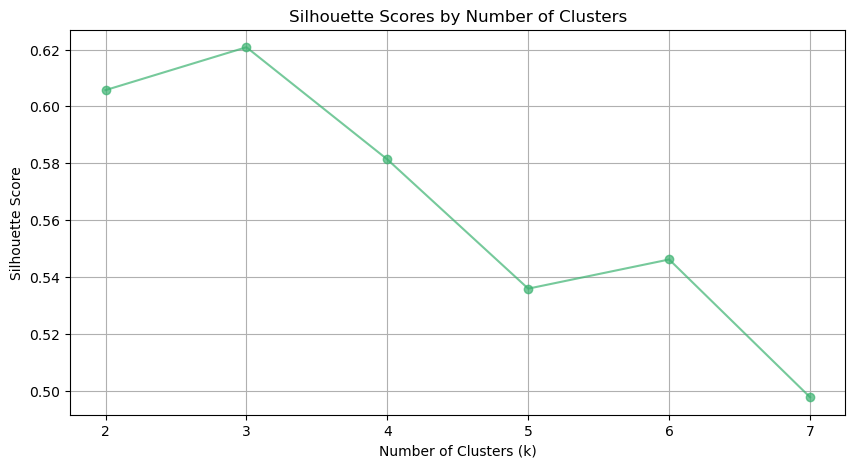

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def compute_silhouette_scores(X, k_values):
    """Compute and plot the silhouette score for a range of k-values starting at 2."""
    scores = []
    
    # use KMeans with 10 trials for a given k-value
    for k in k_values:
        clusterer = KMeans(n_clusters=k, n_init=10)
        labels = clusterer.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, scores, marker='o', linestyle='-', color='mediumseagreen', alpha=0.7)
    plt.title('Silhouette Scores by Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.grid(True)
    plt.show()

k_values = list(range(2, 8))
compute_silhouette_scores(df_pca, k_values)

## Visualize k=(2, 3, 4) clusters

In [ ]:
import seaborn as sns
import plotly.graph_objects as go
import numpy as np

def visualize_clusters_3d(X, k_values, colors):
    """Create 3D scatterplots to visualize the clustering of the best performing k-values."""
    
    for k in k_values:
        # use KMeans with 10 trials for a given k-value
        clusterer = KMeans(n_clusters=k, n_init=10)
        labels = clusterer.fit_predict(X)
        cluster_centers = clusterer.cluster_centers_
        cluster_colors = [f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})" for r, g, b in colors]
        centroid_colors = [cluster_colors[i] for i in range(k)]

        fig_3d = go.Figure()

        # data points
        fig_3d.add_trace(go.Scatter3d(
            x=X[:, 0], y=X[:, 1], z=X[:, 2],
            mode='markers',
            marker=dict(size=2.5, color=[cluster_colors[i] for i in labels], opacity=0.5),
            name='Data Points'
        ))

        # centroids
        fig_3d.add_trace(go.Scatter3d(
            x=cluster_centers[:, 0], y=cluster_centers[:, 1], z=cluster_centers[:, 2],
            mode='markers+text',
            marker=dict(size=12, color='black', symbol='diamond'),
            text=[str(i+1) for i in range(k)],
            textposition='middle center',
            textfont=dict(color=centroid_colors, size=14, family='Arial Black'),
            name='Centroids'
        ))

        title = f'3D Clustered PCA Data (k={k})'
        fig_3d.update_layout(
            title=title,
            scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
            margin=dict(l=0, r=0, b=0, t=40),
            scene_camera=dict(
                eye=dict(x=1.3, y=-1.7, z=1.3),
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=0, z=1),
            ),
            autosize=False, 
            width=1000, 
            height=800
        )

        # save Plotly's HTML files to display on a website
        fig_3d.write_html(f"./kmeans-plots/{title.replace(' ', '')}.html")
        fig_3d.show()
            
# k-values with high silhouette scores
k_values = [2, 3, 4]

# set up colormap
colors = sns.color_palette('Set2')[:max(k_values)]

visualize_clusters_3d(df_pca, k_values, colors)